# Ejemplo 4.2 — Dos pastillas sometidas a un esfuerzo vertical
**Fuente:** Álvarez (2025), §4.10 — *Modificación de la ley de Hooke para tener en cuenta los efectos térmicos*

---

## Planteamiento

Dos pastillas cuadradas están apiladas dentro de una caja de **10 cm de arista interior**.
Cada pastilla es un material **elástico, lineal, homogéneo e isótropo**.
El sistema experimenta un incremento de temperatura $\Delta T = 15\,^\circ\text{C}$.

| Parámetro | Pastilla 1 | Pastilla 2 |
|---|---|---|
| Altura $h$ [m] | 0.25 | 0.12 |
| Módulo de Young $E$ [MPa] | 700 | 400 |
| Coeficiente de Poisson $\nu$ | 0.32 | 0.20 |
| Coef. expansión térmica $\alpha$ [1/°C] | $77\times10^{-6}$ | $9\times10^{-6}$ |

**Objetivo:** Determinar el esfuerzo $\sigma_z$ necesario para que el conjunto se acorte
$\Delta h = -1\,\text{mm}$ en dirección $z$, para dos condiciones de borde:

- **Caso 1:** Pastillas confinadas lateralmente (dentro de la caja) → $\varepsilon_x = \varepsilon_y = 0$
- **Caso 2:** Pastillas sin confinamiento lateral (solo apiladas) → $\sigma_x = \sigma_y = 0$

## Formulación teórica

### Ley de Hooke con efectos térmicos (ec. 4.48 de Álvarez, 2025)

$$
\varepsilon_{ij} = \frac{1}{2G}\sigma_{ij} - \frac{\lambda}{2G(3\lambda+2G)}\sigma_{kk}\delta_{ij} + \alpha\Delta T\,\delta_{ij}
$$

o en forma extendida para materiales isótropos:

$$
\varepsilon_x = \frac{1}{E}(\sigma_x - \nu\sigma_y - \nu\sigma_z) + \alpha\Delta T
$$
$$
\varepsilon_y = \frac{1}{E}(\sigma_y - \nu\sigma_x - \nu\sigma_z) + \alpha\Delta T
$$
$$
\varepsilon_z = \frac{1}{E}(\sigma_z - \nu\sigma_x - \nu\sigma_y) + \alpha\Delta T
$$

---

### Caso 1: Confinamiento lateral ($\varepsilon_x = \varepsilon_y = 0$)

La dilatación cúbica se reduce a $e = \varepsilon_z$. Empleando la forma alternativa de la ley de Hooke (ec. 4.48):

$$
\sigma_z = (\lambda + 2G)\,\varepsilon_z + \frac{E\alpha\Delta T}{2\nu - 1}
\quad \Rightarrow \quad
\varepsilon_z = \frac{\sigma_z - c}{d}
$$

donde:
$$
c = \frac{E\alpha\Delta T}{2\nu - 1}, \qquad d = \lambda + 2G
$$

La compatibilidad de desplazamientos verticales exige:
$$
\Delta h = \varepsilon_{z1}\,h_1 + \varepsilon_{z2}\,h_2 = \frac{\sigma_z - c_1}{d_1}\,h_1 + \frac{\sigma_z - c_2}{d_2}\,h_2
$$

Despejando $\sigma_z$ (ec. 4.51 de Álvarez, 2025):
$$
\boxed{\sigma_z = \frac{d_2\,c_1\,h_1 + d_1\,c_2\,h_2 + d_1\,d_2\,\Delta h}{d_1\,h_2 + d_2\,h_1}}
$$

---

### Caso 2: Sin confinamiento lateral ($\sigma_x = \sigma_y = 0$)

La deformación vertical de cada pastilla se reduce a:
$$
\varepsilon_z = \frac{\sigma_z}{E} + \alpha\Delta T
$$

La compatibilidad de desplazamientos verticales:
$$
\Delta h = \left(\frac{\sigma_z}{E_1} + \alpha_1\Delta T\right)h_1 + \left(\frac{\sigma_z}{E_2} + \alpha_2\Delta T\right)h_2
$$

Despejando $\sigma_z$:
$$
\boxed{\sigma_z = \frac{E_1 E_2\,\bigl[\Delta h - (\alpha_1 h_1 + \alpha_2 h_2)\Delta T\bigr]}{E_1 h_2 + E_2 h_1}}
$$

In [1]:
import numpy as np

# ─────────────────────────────────────────────────────────────
# DATOS DEL PROBLEMA
# ─────────────────────────────────────────────────────────────
h1   = 0.25          # [m]    altura pastilla 1
h2   = 0.12          # [m]    altura pastilla 2
dh   = -0.001        # [m]    acortamiento total deseado (Δh = -1 mm)
dT   = 15.0          # [°C]   incremento de temperatura
lado = 0.10          # [m]    arista de la sección cuadrada de la caja
A    = lado**2       # [m²]   área transversal

# Propiedades materiales
E1     = 700e6       # [Pa]   módulo de Young – pastilla 1
nu1    = 0.32        # [-]    coeficiente de Poisson – pastilla 1
alpha1 = 77e-6       # [1/°C] coeficiente de expansión térmica – pastilla 1

E2     = 400e6       # [Pa]   módulo de Young – pastilla 2
nu2    = 0.20        # [-]    coeficiente de Poisson – pastilla 2
alpha2 = 9e-6        # [1/°C] coeficiente de expansión térmica – pastilla 2

print("Datos cargados correctamente.")

Datos cargados correctamente.


In [2]:
# ─────────────────────────────────────────────────────────────
# CONSTANTES ELÁSTICAS DE LAMÉ
# λ = E ν / [(1+ν)(1−2ν)]     G = E / [2(1+ν)]
# ─────────────────────────────────────────────────────────────
def lame_constants(E, nu):
    """Devuelve las constantes de Lamé (lambda, G) para un material isótropo."""
    lam = E * nu / ((1 + nu) * (1 - 2*nu))
    G   = E / (2 * (1 + nu))
    return lam, G

lam1, G1 = lame_constants(E1, nu1)
lam2, G2 = lame_constants(E2, nu2)

print(f"Pastilla 1:  λ₁ = {lam1/1e6:.4f} MPa   G₁ = {G1/1e6:.4f} MPa")
print(f"Pastilla 2:  λ₂ = {lam2/1e6:.4f} MPa   G₂ = {G2/1e6:.4f} MPa")

Pastilla 1:  λ₁ = 471.3805 MPa   G₁ = 265.1515 MPa
Pastilla 2:  λ₂ = 111.1111 MPa   G₂ = 166.6667 MPa


## Caso 1: Pastillas confinadas lateralmente ($\varepsilon_x = \varepsilon_y = 0$)

In [3]:
# ─────────────────────────────────────────────────────────────
# CASO 1: CONFINAMIENTO LATERAL  (εx = εy = 0)
# ─────────────────────────────────────────────────────────────

# Constantes auxiliares c = E α ΔT / (2ν − 1)   y   d = λ + 2G
c1 = E1 * alpha1 * dT / (2*nu1 - 1)
d1 = lam1 + 2*G1

c2 = E2 * alpha2 * dT / (2*nu2 - 1)
d2 = lam2 + 2*G2

print("Constantes para el Caso 1:")
print(f"  c₁ = {c1/1e6:.6f} MPa   d₁ = {d1/1e6:.4f} MPa")
print(f"  c₂ = {c2/1e6:.6f} MPa   d₂ = {d2/1e6:.4f} MPa")

# Esfuerzo σz  (ec. 4.51, Álvarez 2025)
sz_caso1 = (d2*c1*h1 + d1*c2*h2 + d1*d2*dh) / (d1*h2 + d2*h1)

# Fuerza equivalente
F_caso1 = sz_caso1 * A

# Verificación: deformaciones unitarias y desplazamiento total
ez1_caso1 = (sz_caso1 - c1) / d1
ez2_caso1 = (sz_caso1 - c2) / d2
dh_check1 = ez1_caso1 * h1 + ez2_caso1 * h2

print("\n── RESULTADOS CASO 1 (confinado lateralmente) ──")
print(f"  σz          = {sz_caso1/1e6:.6f} MPa")
print(f"  Fuerza F    = {F_caso1/1e3:.4f} kN")
print(f"  εz₁         = {ez1_caso1:.6e}")
print(f"  εz₂         = {ez2_caso1:.6e}")
print(f"  Δh verificado = {dh_check1*1e3:.6f} mm  (debe ser -1.000 mm)")

Constantes para el Caso 1:
  c₁ = -2.245833 MPa   d₁ = 1001.6835 MPa
  c₂ = -0.090000 MPa   d₂ = 444.4444 MPa

── RESULTADOS CASO 1 (confinado lateralmente) ──
  σz          = -3.050185 MPa
  Fuerza F    = -30.5019 kN
  εz₁         = -8.030000e-04
  εz₂         = -6.660417e-03
  Δh verificado = -1.000000 mm  (debe ser -1.000 mm)


## Caso 2: Pastillas sin confinamiento lateral ($\sigma_x = \sigma_y = 0$)

In [4]:
# ─────────────────────────────────────────────────────────────
# CASO 2: SIN CONFINAMIENTO LATERAL  (σx = σy = 0)
# ─────────────────────────────────────────────────────────────

# σz = E1 E2 [Δh − (α1 h1 + α2 h2) ΔT] / (E1 h2 + E2 h1)
sz_caso2 = (E1 * E2 * (dh - (alpha1*h1 + alpha2*h2)*dT)) / (E1*h2 + E2*h1)

# Fuerza equivalente
F_caso2 = sz_caso2 * A

# Verificación: deformaciones unitarias y desplazamiento total
ez1_caso2 = sz_caso2 / E1 + alpha1 * dT
ez2_caso2 = sz_caso2 / E2 + alpha2 * dT
dh_check2 = ez1_caso2 * h1 + ez2_caso2 * h2

print("── RESULTADOS CASO 2 (sin confinamiento lateral) ──")
print(f"  σz          = {sz_caso2/1e6:.6f} MPa")
print(f"  Fuerza F    = {F_caso2/1e3:.5f} kN")
print(f"  εz₁         = {ez1_caso2:.6e}")
print(f"  εz₂         = {ez2_caso2:.6e}")
print(f"  Δh verificado = {dh_check2*1e3:.6f} mm  (debe ser -1.000 mm)")

── RESULTADOS CASO 2 (sin confinamiento lateral) ──
  σz          = -1.985793 MPa
  Fuerza F    = -19.85793 kN
  εz₁         = -1.681848e-03
  εz₂         = -4.829484e-03
  Δh verificado = -1.000000 mm  (debe ser -1.000 mm)


## Resumen comparativo

In [5]:
# ─────────────────────────────────────────────────────────────
# RESUMEN Y COMPARACIÓN
# ─────────────────────────────────────────────────────────────
print("=" * 55)
print(f"{'RESUMEN COMPARATIVO':^55}")
print("=" * 55)
print(f"{'Magnitud':<30} {'Caso 1':>11} {'Caso 2':>11}")
print("-" * 55)
print(f"{'σz  [MPa]':<30} {sz_caso1/1e6:>11.4f} {sz_caso2/1e6:>11.5f}")
print(f"{'F   [kN]':<30} {F_caso1/1e3:>11.3f} {F_caso2/1e3:>11.3f}")
print(f"{'εz₁ [-]':<30} {ez1_caso1:>11.4e} {ez1_caso2:>11.4e}")
print(f"{'εz₂ [-]':<30} {ez2_caso1:>11.4e} {ez2_caso2:>11.4e}")
print(f"{'Δh verificado [mm]':<30} {dh_check1*1e3:>11.4f} {dh_check2*1e3:>11.4f}")
print("=" * 55)

razon = abs(sz_caso1 / sz_caso2)
print(f"\nEl Caso 1 requiere {razon:.2f}× más esfuerzo que el Caso 2.")
print("(El confinamiento lateral incrementa la rigidez aparente del conjunto.)")

                  RESUMEN COMPARATIVO                  
Magnitud                            Caso 1      Caso 2
-------------------------------------------------------
σz  [MPa]                          -3.0502    -1.98579
F   [kN]                           -30.502     -19.858
εz₁ [-]                        -8.0300e-04 -1.6818e-03
εz₂ [-]                        -6.6604e-03 -4.8295e-03
Δh verificado [mm]                 -1.0000     -1.0000

El Caso 1 requiere 1.54× más esfuerzo que el Caso 2.
(El confinamiento lateral incrementa la rigidez aparente del conjunto.)


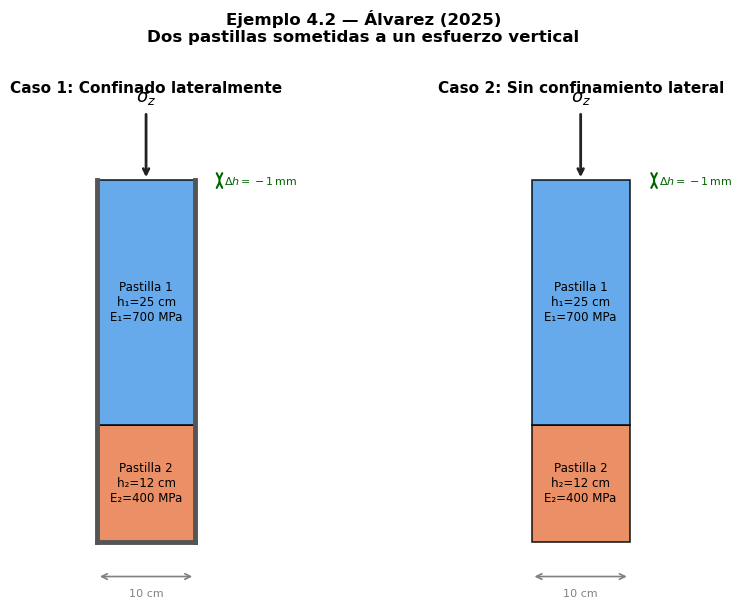

Figura guardada como 'esquema_pastillas.png'


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────────────────────
# FIGURA 1: Esquema del problema
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

colores = {'pastilla1': '#4C9BE8', 'pastilla2': '#E87B4C',
           'caja': '#555555', 'flecha': '#222222'}

for ax, titulo, con_caja in zip(axes,
                                 ['Caso 1: Confinado lateralmente',
                                  'Caso 2: Sin confinamiento lateral'],
                                 [True, False]):
    ax.set_xlim(-0.05, 0.15)
    ax.set_ylim(-0.06, 0.45)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(titulo, fontsize=11, fontweight='bold')

    x0, ancho = 0.0, 0.10

    # Pastilla 2 (inferior)
    rect2 = mpatches.FancyBboxPatch((x0, 0.0), ancho, h2,
                                    boxstyle='square,pad=0',
                                    facecolor=colores['pastilla2'],
                                    edgecolor='k', linewidth=1.2, alpha=0.85)
    ax.add_patch(rect2)
    ax.text(x0 + ancho/2, h2/2, f'Pastilla 2\nh₂={h2*100:.0f} cm\nE₂={E2/1e6:.0f} MPa',
            ha='center', va='center', fontsize=8.5)

    # Pastilla 1 (superior)
    rect1 = mpatches.FancyBboxPatch((x0, h2), ancho, h1,
                                    boxstyle='square,pad=0',
                                    facecolor=colores['pastilla1'],
                                    edgecolor='k', linewidth=1.2, alpha=0.85)
    ax.add_patch(rect1)
    ax.text(x0 + ancho/2, h2 + h1/2,
            f'Pastilla 1\nh₁={h1*100:.0f} cm\nE₁={E1/1e6:.0f} MPa',
            ha='center', va='center', fontsize=8.5)

    # Caja (solo Caso 1)
    if con_caja:
        lw_caja = 3.5
        # Paredes laterales
        ax.plot([x0, x0], [0, h1+h2], color=colores['caja'], lw=lw_caja)
        ax.plot([x0+ancho, x0+ancho], [0, h1+h2],
                color=colores['caja'], lw=lw_caja)
        # Base
        ax.plot([x0, x0+ancho], [0, 0], color=colores['caja'], lw=lw_caja)

    # Flecha de carga σz
    ytop = h1 + h2
    ax.annotate('', xy=(x0 + ancho/2, ytop),
                xytext=(x0 + ancho/2, ytop + 0.07),
                arrowprops=dict(arrowstyle='->', color=colores['flecha'],
                                lw=2.0))
    ax.text(x0 + ancho/2, ytop + 0.075, r'$\sigma_z$',
            ha='center', va='bottom', fontsize=13)

    # Acotación Δh
    ax.annotate('', xy=(x0 + ancho + 0.025, ytop - 0.001),
                xytext=(x0 + ancho + 0.025, ytop),
                arrowprops=dict(arrowstyle='<->', color='darkgreen', lw=1.5))
    ax.text(x0 + ancho + 0.030, ytop - 0.0005,
            r'$\Delta h = -1\,\mathrm{mm}$',
            ha='left', va='center', fontsize=8, color='darkgreen')

    # Dimensión lateral
    ax.annotate('', xy=(x0, -0.035), xytext=(x0+ancho, -0.035),
                arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
    ax.text(x0 + ancho/2, -0.048, '10 cm',
            ha='center', va='top', fontsize=8, color='gray')

fig.suptitle('Ejemplo 4.2 — Álvarez (2025)\nDos pastillas sometidas a un esfuerzo vertical',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('esquema_pastillas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada como 'esquema_pastillas.png'")

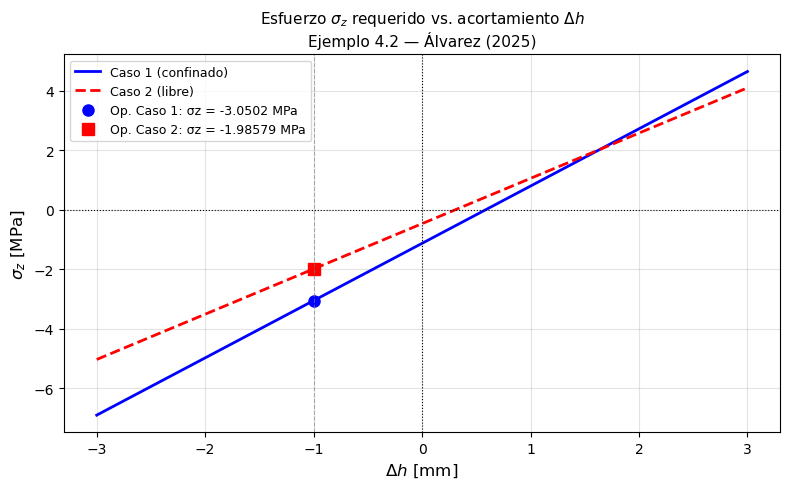

Figura guardada como 'sz_vs_dh.png'


In [7]:
# ─────────────────────────────────────────────────────────────
# FIGURA 2: Variación de σz en función de Δh
#           (para verificar linealidad y comparar los dos casos)
# ─────────────────────────────────────────────────────────────
dh_vec = np.linspace(-0.003, 0.003, 300)   # rango de Δh [m]

# Caso 1
sz1_vec = (d2*c1*h1 + d1*c2*h2 + d1*d2*dh_vec) / (d1*h2 + d2*h1)

# Caso 2
sz2_vec = (E1*E2*(dh_vec - (alpha1*h1 + alpha2*h2)*dT)) / (E1*h2 + E2*h1)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(dh_vec*1e3, sz1_vec/1e6, 'b-',  lw=2, label='Caso 1 (confinado)')
ax.plot(dh_vec*1e3, sz2_vec/1e6, 'r--', lw=2, label='Caso 2 (libre)')

# Punto de operación
ax.plot(dh*1e3, sz_caso1/1e6, 'bo', ms=8,
        label=f'Op. Caso 1: σz = {sz_caso1/1e6:.4f} MPa')
ax.plot(dh*1e3, sz_caso2/1e6, 'rs', ms=8,
        label=f'Op. Caso 2: σz = {sz_caso2/1e6:.5f} MPa')

ax.axhline(0, color='k', lw=0.8, ls=':')
ax.axvline(0, color='k', lw=0.8, ls=':')
ax.axvline(dh*1e3, color='gray', lw=0.8, ls='--', alpha=0.6)

ax.set_xlabel(r'$\Delta h$ [mm]', fontsize=12)
ax.set_ylabel(r'$\sigma_z$ [MPa]', fontsize=12)
ax.set_title('Esfuerzo $\\sigma_z$ requerido vs. acortamiento $\\Delta h$\n'
             'Ejemplo 4.2 — Álvarez (2025)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig('sz_vs_dh.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada como 'sz_vs_dh.png'")

## Interpretación física de los resultados

| | Caso 1 (confinado) | Caso 2 (libre) |
|---|---|---|
| $\sigma_z$ | ≈ −3.050 MPa | ≈ −1.986 MPa |
| $F$ | ≈ −30.50 kN | ≈ −19.86 kN |

**El Caso 1 requiere mayor esfuerzo** porque las paredes de la caja impiden la expansión
lateral. Al estar confinadas ($\varepsilon_x = \varepsilon_y = 0$), se generan
esfuerzos de confinamiento $\sigma_x$ y $\sigma_y$ que incrementan la rigidez
aparente del conjunto en dirección $z$ (efecto del módulo constreñido $M = \lambda + 2G > E$).

En el Caso 2, las pastillas son libres de deformarse lateralmente, por lo que
la rigidez corresponde directamente al módulo de Young $E$, que es menor.

Adicionalmente, el calentamiento $\Delta T = 15\,^\circ$C tiende a **dilatar**
el conjunto, de modo que el esfuerzo de compresión requerido es mayor que el
que se necesitaría en ausencia de temperatura.